# Laplace UQ 验证 · generative uncertainty on the toy diffusion model

把论文 [Generative Uncertainty in Diffusion Models](https://arxiv.org/abs/2502.20946) 的 **last-layer Laplace** 方法搬到我们的玩具扩散模型上，**验证一个问题：Laplace 得到的 generative uncertainty，是否真的能反映样本离数据流形多远（off-support ratio）？**

玩具问题有 ground truth（已知 16 维子空间 A，可直接算 off-ratio），所以适合检验 UQ 准不准——这是搬到 metamaterial（没有 ground truth）之前的验证步骤。

**方法**（适配自论文）：
1. 对训好的 Unet1D 的**最后一层** `final_conv` 拟合对角 Laplace（扩散损失的 empirical Fisher）→ 权重后验 `N(θ_MAP, Σ)`。
2. 从后验采 **M 个权重**，每个用 **DDIM(η=0) + 同一批固定噪声** 确定性生成 → 每个样本得 M 个版本。
3. **不确定性 = M 个版本的熵**（论文 `gaussian_entropy`；x 本身就是特征，无需 CLIP）。
4. 和已知 off-ratio 做相关性 + 拒绝采样。

> 依赖：`laplace-torch` + `curvlinops<3`（已装）。用 CPU + d16 测试 checkpoint。需要 `diffusion_uq/generative_uncertainty` 在 sys.path。

In [1]:
# ---- 环境准备 ----
%matplotlib inline
import os, sys
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ["CUDA_VISIBLE_DEVICES"] = ""        # 测试版强制 CPU；UQ 用 DDIM(η=0) 确定性

# 定位 GGDMOptim/simulations（含 train.py）
def _find(anchor, fallback, *extra):
    here = os.getcwd()
    cands = [here, os.path.dirname(here), os.path.join(here, "simulations"),
             os.path.join(os.path.dirname(here), "simulations"), *extra, fallback]
    return next((c for c in cands if os.path.exists(os.path.join(c, anchor))), fallback)

SIM_DIR = _find("train.py", r"H:\My Drive\Research\DAM\code\GGDMOptim\simulations")
GU_DIR  = _find("diffusion_laplace.py",
                r"H:\My Drive\Research\DAM\code\diffusion_uq\generative_uncertainty")
os.chdir(SIM_DIR)
for p in (SIM_DIR, GU_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import vector_to_parameters
from scipy.stats import pearsonr, spearmanr
from unet_1d import Unet1D
from diffusion import GuidedGaussianDiffusion, extract
from train import LinearLatentData, set_seed
from diffusion_laplace import DiffusionLLDiagLaplace          # 论文代码

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
set_seed(2345)
device = torch.device("cpu")

# 论文 semantic_likelihood.gaussian_entropy 内联（原文件顶部 import clip，这里用不到）
def gaussian_entropy(mu_array, sigma_squared=1e-3):
    if mu_array.ndim == 2:
        mu_array = mu_array[np.newaxis, ...]
    _, _, D = mu_array.shape
    diag = np.clip(np.mean(mu_array**2, axis=1) - np.mean(mu_array, axis=1) ** 2, 0.0, None)
    return 0.5 * np.sum(np.log(diag + sigma_squared), axis=1) + 0.5 * D * (np.log(2 * np.pi) + 1)

# 数据生成器（提供 ground-truth off-ratio）+ 训好的 d16 模型
g = LinearLatentData("data/linear_latent/hyperparameters_test.npz", d_inner=4, d_outer=16, r_off=9)
diff = GuidedGaussianDiffusion(model=Unet1D(dim=16, conditional=False), image_size=16, timesteps=200)
diff.load_state_dict(torch.load("checkpoints/pretrained/linear_latent_test_d16_epoch_40.pth",
                                map_location=device)["model_state_dict"])
diff.eval()

# Unet1D conditional=False，传非 None labels 会 crash；wrapper 忽略 labels 走无条件
class UncondDenoiser(nn.Module):
    def __init__(self, m): super().__init__(); self.model = m
    def forward(self, x, t, labels=None): return self.model(x, t, None)
wrapped = UncondDenoiser(diff.model)

# Laplace 的输入/输出 glue：clean x0 → 随机 t 加噪得 x_t，target=噪声 ε
def f_preprocess(X, y, dev):
    X = X.to(dev).float(); B = X.shape[0]
    t = torch.randint(0, diff.num_timesteps, (B,), device=dev).long()
    eps = torch.randn_like(X)
    xt = extract(diff.sqrt_alphas_cumprod, t, X.shape) * X + extract(diff.sqrt_one_minus_alphas_cumprod, t, X.shape) * eps
    return (t, xt, torch.zeros(B, device=dev, dtype=torch.long)), eps
def f_postprocess(out): return out

print("SIM_DIR:", SIM_DIR)
print("GU_DIR :", GU_DIR)
print("模型已加载 | device:", device)

SIM_DIR: h:\My Drive\Research\DAM\code\GGDMOptim\simulations
GU_DIR : H:\My Drive\Research\DAM\code\diffusion_uq\generative_uncertainty
模型已加载 | device: cpu


## Part 1 · 拟合 last-layer Laplace

冻结除 `final_conv` 外的所有权重，用扩散训练损失的对角 empirical Fisher，得到最后一层 17 个参数的高斯后验 `N(θ_MAP, Σ)`。

In [2]:
N_FIT = 2048
x0_fit = torch.from_numpy(g.generate_x(N_FIT)).float()
loader = DataLoader(TensorDataset(x0_fit, torch.zeros(N_FIT, dtype=torch.long)), batch_size=128)

la = DiffusionLLDiagLaplace(
    wrapped, last_layer_name="final_conv",
    f_preprocess_la_input=f_preprocess, f_postprocess_la_output=f_postprocess,
    likelihood="regression", sigma_noise=1.0, prior_precision=1.0,
)
la.fit(loader)

theta_map = la.mean.clone()
theta_std = la.posterior_variance.sqrt().clone()
fc = diff.model.final_conv
print("last-layer 参数量:", theta_map.numel(), "(16 权重 + 1 偏置)")
print("后验 std 均值 = %.4e" % theta_std.mean().item())

Total parameters: 1127233
Total parameters with grad: 1127233
Total parameters in final layer: 17
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
last-layer 参数量: 17 (16 权重 + 1 偏置)
后验 std 均值 = 1.8706e-02


## Part 2 · 采 M 个权重 + DDIM 确定性生成

从后验采 `M` 个权重（`m=0` 用 MAP 不扰动）。每个权重都用 **DDIM(η=0) + 同一批固定初始噪声** 生成同一批样本，
保证**唯一变量是权重**（epistemic），不被 DDPM 采样噪声污染。每个样本得到 M 个版本 → `(n, M, 16)`。

In [ ]:
n, M = 150, 6
set_seed(0)
z = torch.randn(n, 16)                 # 固定初始噪声，所有权重共用

gens = []
for m in range(M):
    vec = theta_map if m == 0 else theta_map + theta_std * torch.randn_like(theta_std)
    vector_to_parameters(vec, [fc.weight, fc.bias])      # 把权重塞进 final_conv
    with torch.no_grad():
        x0_m = diff.ddim_sample(noise=z, eta=0.0, progress=False)
    gens.append(x0_m.cpu().numpy())
vector_to_parameters(theta_map, [fc.weight, fc.bias])    # 复原 MAP

gens = np.stack(gens, axis=1)          # (n, M, 16)
print("生成结果 shape:", gens.shape)
print("跨 M 的平均 per-dim 方差 = %.3f (数据尺度 ~0.5；偏大说明部分轨迹发散)" % gens.var(axis=1).mean())

## Part 3 · generative uncertainty vs 已知 off-ratio

- **不确定性** = M 个版本的熵（`gaussian_entropy`）
- **ground truth** = MAP 生成样本（`m=0`）的 off-support ratio
- 看两者相关性：正相关 = UQ 能当 manifold-distance 的代理

UQ vs off-ratio:  Pearson=0.440   Spearman=0.595


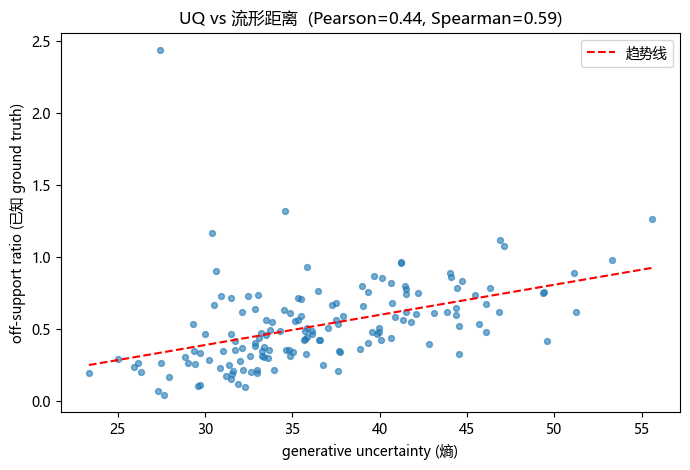

In [4]:
unc  = gaussian_entropy(gens, sigma_squared=1e-3)   # (n,) 不确定性
offr = g.off_support_ratio(gens[:, 0, :])           # (n,) 已知 off-ratio（MAP 生成）

pr, _ = pearsonr(unc, offr)
sr, _ = spearmanr(unc, offr)
print("UQ vs off-ratio:  Pearson=%.3f   Spearman=%.3f" % (pr, sr))

plt.figure(figsize=(7, 4.8))
plt.scatter(unc, offr, s=18, alpha=0.6)
b, a = np.polyfit(unc, offr, 1)                     # 拟合趋势线
xs = np.linspace(unc.min(), unc.max(), 50)
plt.plot(xs, a + b * xs, "r--", lw=1.5, label="趋势线")
plt.xlabel("generative uncertainty (熵)"); plt.ylabel("off-support ratio (已知 ground truth)")
plt.title("UQ vs 流形距离  (Pearson=%.2f, Spearman=%.2f)" % (pr, sr)); plt.legend()
plt.tight_layout(); plt.show()

## Part 4 · 拒绝采样 demo

按不确定性从低到高排序，只保留低不确定性的前 k%，看存活样本的 off-ratio 是否更贴流形。

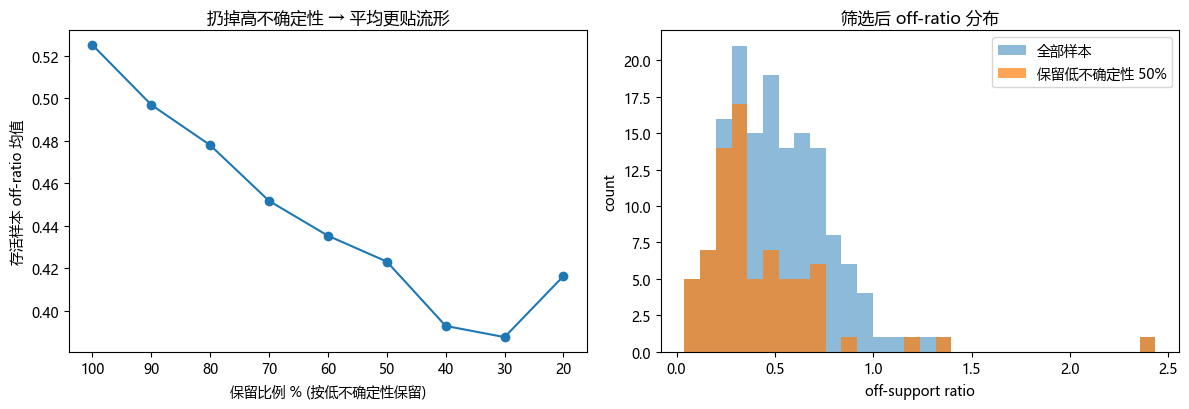

全部     : off-ratio mean=0.525  max=2.435
保留 50% : off-ratio mean=0.423  max=2.435


In [5]:
keeps = np.linspace(1.0, 0.2, 9)
order = np.argsort(unc)                  # 低不确定性在前
mean_off = [offr[order[:int(n*k)]].mean() for k in keeps]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(keeps*100, mean_off, marker="o")
ax[0].invert_xaxis()
ax[0].set_xlabel("保留比例 % (按低不确定性保留)"); ax[0].set_ylabel("存活样本 off-ratio 均值")
ax[0].set_title("扔掉高不确定性 → 平均更贴流形")

ax[1].hist(offr, bins=30, alpha=0.5, label="全部样本")
ax[1].hist(offr[order[:n//2]], bins=30, alpha=0.7, label="保留低不确定性 50%")
ax[1].set_xlabel("off-support ratio"); ax[1].set_ylabel("count"); ax[1].legend()
ax[1].set_title("筛选后 off-ratio 分布")
plt.tight_layout(); plt.show()

lo = offr[order[:n//2]]
print(f"全部     : off-ratio mean={offr.mean():.3f}  max={offr.max():.3f}")
print(f"保留 50% : off-ratio mean={lo.mean():.3f}  max={lo.max():.3f}")

## 小结（诚实版）

**结论**：Laplace generative uncertainty 与已知 off-ratio **正相关**（Spearman ≈ 0.6），按不确定性拒绝采样能**降低平均 off-ratio** → 在有 ground-truth 的玩具上，**初步验证了 UQ 可当 manifold-distance 的代理**。

**Caveats（要带着搬去 metamaterial 时记住）**：
1. 相关性是**中等**（~0.6），不是接近完美——抓趋势，但单个最差离群点可能漏掉。
2. 跨 M 方差偏大：扰动权重后部分 **DDIM 轨迹发散**（欠训模型 + 确定性采样的已知不稳定），"不确定性"**混入了轨迹不稳定性**，不是纯 epistemic。
3. 模型欠训（d16、12 分钟）。**充分训练的 64 维论文模型大概率给更干净的信号。**

**下一步可选**：① 用 `la.optimize_prior_precision()` 校准后验；② 换 64 维充分训练模型重做；③ 直接把这套（Laplace 拟合 → M 权重 → 确定性生成 → 熵）搬到 acoustic metamaterial 的扩散模型上，用"生成结构的物理合法性/可制造性"代替 off-ratio 做验证。